# KNN

## Importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.neighbors import KNeighborsClassifier

In [4]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [5]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [6]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

Impotamos las librerias

## Cargado de datos

In [7]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [9]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

Hacemos un cargado de los datos

## Funciones usadas

In [10]:
from funciones import *

## Modelo KNN benchmark

In [11]:
pipe_KNN = crear_pipeline(KNeighborsClassifier(n_neighbors=5), tipo="normal")

In [12]:
start = time.time()
model_pipe=pipe_KNN.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.01 minutos


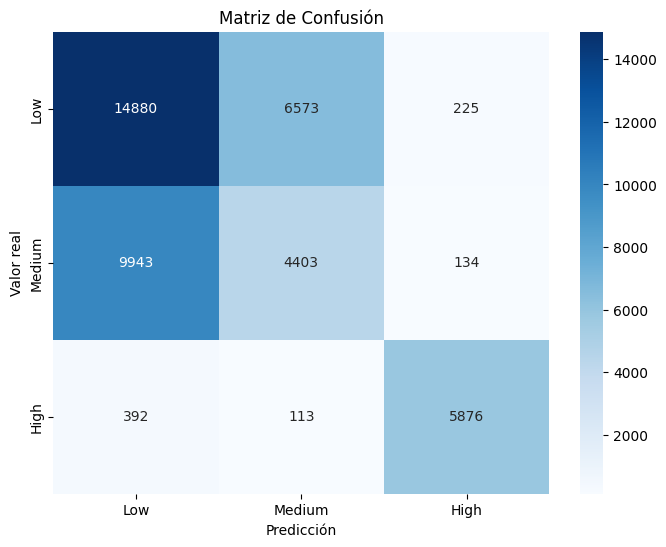


Classification Report:

              precision    recall  f1-score   support

         Low       0.59      0.69      0.63     21678
      Medium       0.40      0.30      0.34     14480
        High       0.94      0.92      0.93      6381

    accuracy                           0.59     42539
   macro avg       0.64      0.64      0.64     42539
weighted avg       0.58      0.59      0.58     42539



{'Accuracy': 0.5914337431533416,
 'Precision (macro)': 0.6432022958956795,
 'Recall (macro)': 0.637114523546006,
 'F1-score (macro)': 0.6368510863624467,
 'ROC-AUC': 0.7339356292651235}

In [13]:
evaluar_modelo(model_pipe, X_test, y_test)

Podemos observar que en general el modelo tiene scores bastante aceptables para Low y High pero medium se queda un poco relegado en la mayoria de scores, High tiene muy buenos scores y la mayoria de veces se predice de buena manera

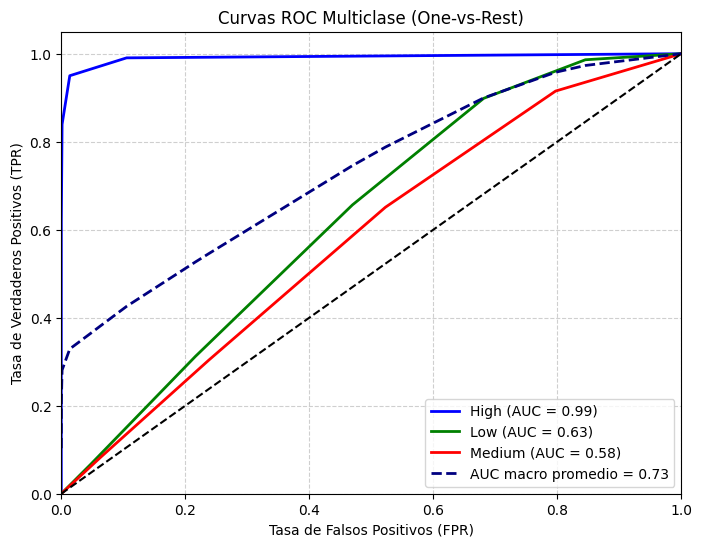


===== AUC por clase =====
High: 0.9914
Low: 0.6290
Medium: 0.5814
AUC macro promedio: 0.7339


({0: 0.9913924394700897, 1: 0.6290215063811256, 2: 0.5813929419441551},
 0.7339356292651236)

In [14]:
plot_roc_multiclass(model_pipe, X_test, y_test)

## Balanceo

### SMOTE

In [15]:
pipe_KNN_bal = crear_pipeline(KNeighborsClassifier(n_neighbors=5), tipo="balanceo_smote")

In [16]:
start = time.time()
model_pipe_bal=pipe_KNN_bal.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.07 minutos


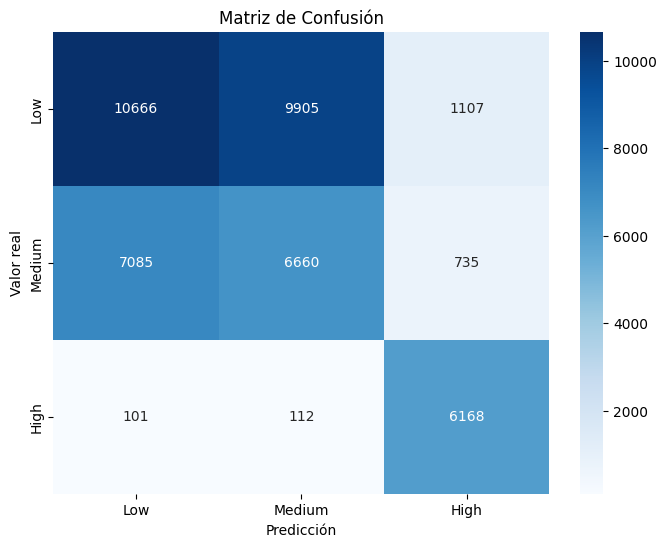


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.49      0.54     21678
      Medium       0.40      0.46      0.43     14480
        High       0.77      0.97      0.86      6381

    accuracy                           0.55     42539
   macro avg       0.59      0.64      0.61     42539
weighted avg       0.56      0.55      0.55     42539



{'Accuracy': 0.5522931897787913,
 'Precision (macro)': 0.5889526418329918,
 'Recall (macro)': 0.6395279874910905,
 'F1-score (macro)': 0.608118491289356,
 'ROC-AUC': 0.7384740219611978}

In [17]:
evaluar_modelo(model_pipe_bal, X_test, y_test)

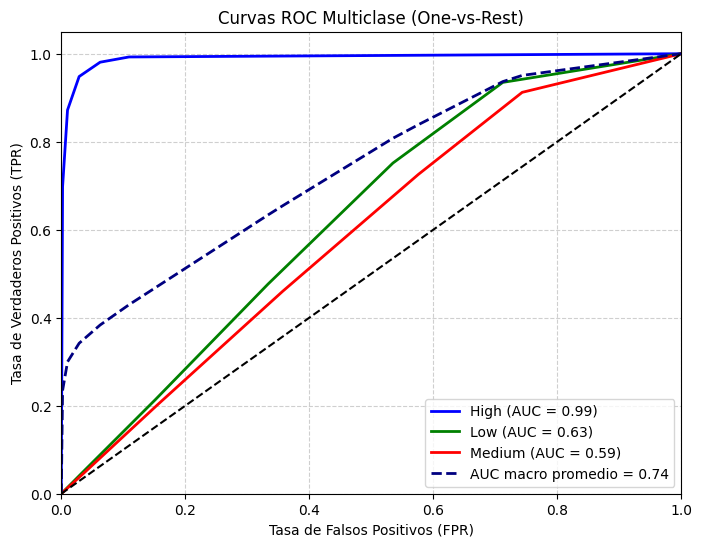


===== AUC por clase =====
High: 0.9901
Low: 0.6306
Medium: 0.5947
AUC macro promedio: 0.7385


({0: 0.9901264365864217, 1: 0.6305749031989089, 2: 0.594720726098263},
 0.7384740219611978)

In [18]:
plot_roc_multiclass(model_pipe_bal, X_test, y_test)

El modelo Smote presenta un excelente desempeño para la clase “High” (AUC = 0.9867), demostrando una alta capacidad para identificar correctamente a los pacientes con alto riesgo de cáncer de tiroides.

En contraste, las clases “Low” (AUC = 0.6296) y “Medium” (AUC = 0.5826) muestran un rendimiento considerablemente menor, lo que indica que el modelo tiene dificultad para diferenciar entre niveles bajos e intermedios de riesgo, posiblemente debido al desbalance en los datos o a la similitud de patrones entre estas clases.

El AUC macro promedio (0.7330) refleja un buen rendimiento global, aunque con una clara asimetría en la capacidad predictiva entre clases. Esto sugiere que el modelo prioriza correctamente los casos de alto riesgo, lo cual puede ser útil desde una perspectiva clínica, pero sería recomendable ajustar el balance de clases o los umbrales de decisión para mejorar la detección de los casos de menor riesgo.

### ADASYN

In [19]:
pipe_KNN_ads = crear_pipeline(KNeighborsClassifier(), tipo="balanceo_adasyn")


In [20]:
start = time.time()
model_pipe_ads = pipe_KNN_ads.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.24 minutos


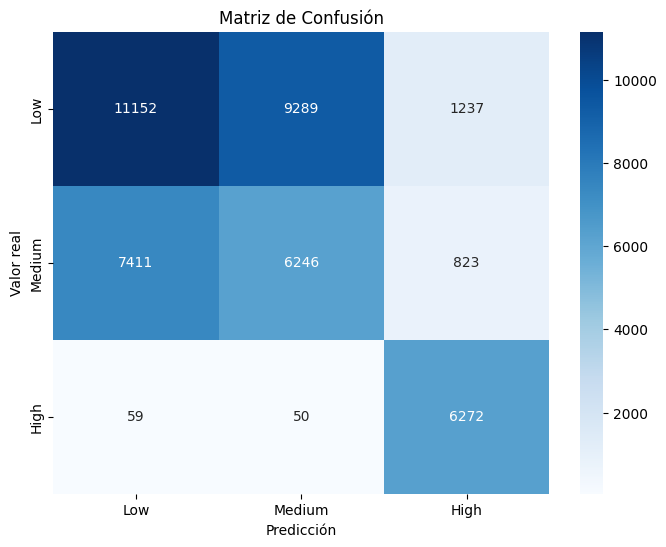


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.51      0.55     21678
      Medium       0.40      0.43      0.42     14480
        High       0.75      0.98      0.85      6381

    accuracy                           0.56     42539
   macro avg       0.58      0.64      0.61     42539
weighted avg       0.55      0.56      0.55     42539



{'Accuracy': 0.55643056959496,
 'Precision (macro)': 0.5841306581301879,
 'Recall (macro)': 0.6429034101440996,
 'F1-score (macro)': 0.6071760778826573,
 'ROC-AUC': 0.7408387017600878}

In [21]:
evaluar_modelo(model_pipe_ads, X_test, y_test)

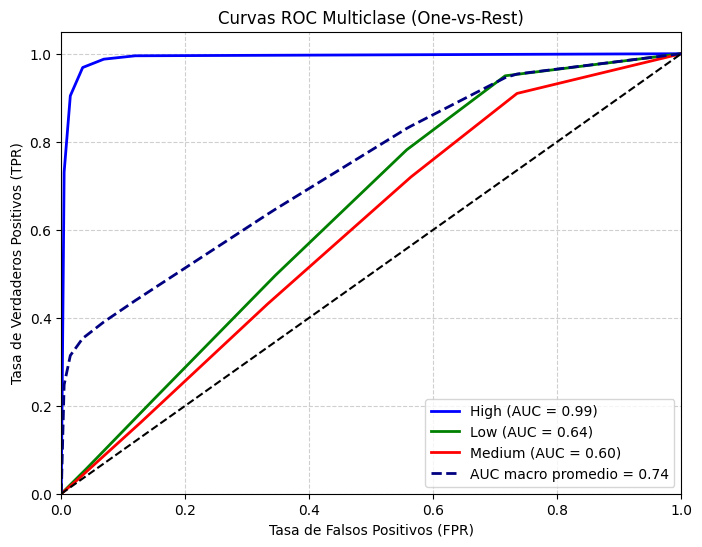


===== AUC por clase =====
High: 0.9907
Low: 0.6353
Medium: 0.5965
AUC macro promedio: 0.7408


({0: 0.9907415172811653, 1: 0.6353199021447649, 2: 0.5964546858543334},
 0.7408387017600879)

In [22]:
plot_roc_multiclass(model_pipe_ads, X_test, y_test)

El modelo ADASYN presenta un excelente desempeño para la clase “High” (AUC = 0.9885), demostrando una alta capacidad para identificar correctamente a los pacientes con alto riesgo de cáncer de tiroides.

En contraste, las clases “Low” (AUC = 0.6358) y “Medium” (AUC = 0.5939) muestran un rendimiento considerablemente menor, lo que indica que el modelo tiene dificultad para diferenciar entre niveles bajos e intermedios de riesgo, posiblemente debido al desbalance en los datos o a la similitud de patrones entre estas clases.

El AUC macro promedio (0.7394) refleja un buen rendimiento global, aunque con una clara asimetría en la capacidad predictiva entre clases. 

## Optimizaciones computacionales para el tiempo

se realizo la optimizacion mediante kd, debido a tener un numero mediano de dimensiones en el train, el cual no es tan grande

In [23]:
pipe_KNN_kd=crear_pipeline(KNeighborsClassifier(n_neighbors=5,algorithm='kd_tree'),'balanceo_smote')

In [24]:
start = time.time()
model_pipe_kd=pipe_KNN_kd.fit(X_train,y_train)
end = time.time()
print(f"Tiempo de ejecución: {(end - start)/60:.2f} minutos")

Tiempo de ejecución: 0.10 minutos


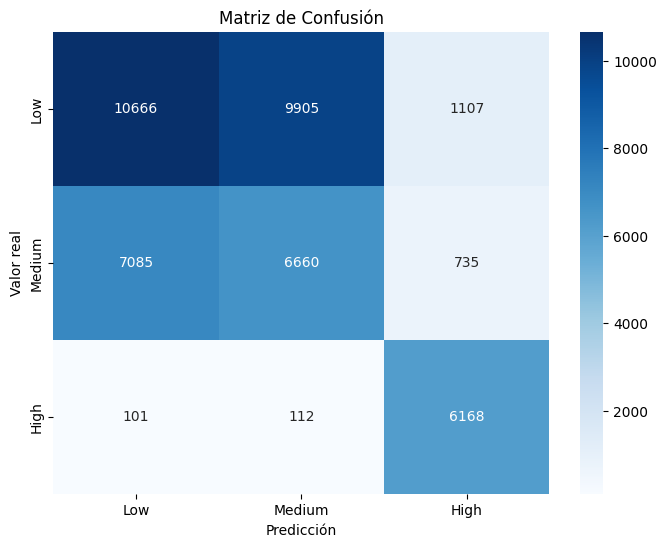


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.49      0.54     21678
      Medium       0.40      0.46      0.43     14480
        High       0.77      0.97      0.86      6381

    accuracy                           0.55     42539
   macro avg       0.59      0.64      0.61     42539
weighted avg       0.56      0.55      0.55     42539



{'Accuracy': 0.5522931897787913,
 'Precision (macro)': 0.5889526418329918,
 'Recall (macro)': 0.6395279874910905,
 'F1-score (macro)': 0.608118491289356,
 'ROC-AUC': 0.7384740219611978}

In [25]:
evaluar_modelo(model_pipe_kd, X_test, y_test)

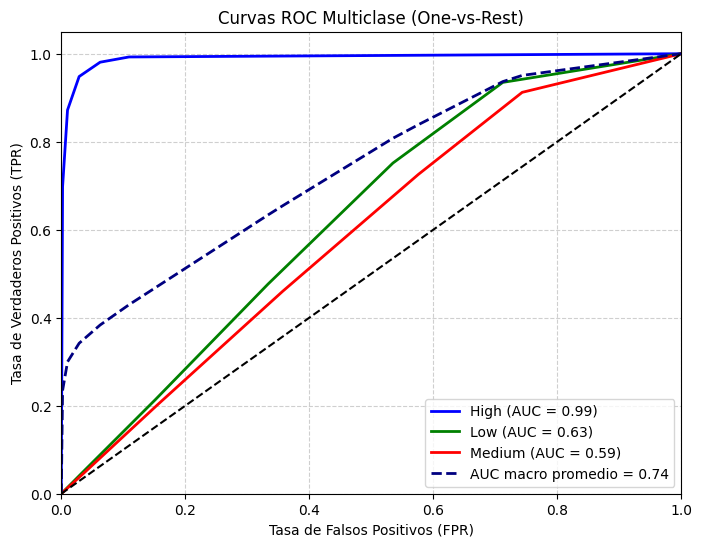


===== AUC por clase =====
High: 0.9901
Low: 0.6306
Medium: 0.5947
AUC macro promedio: 0.7385


({0: 0.9901264365864217, 1: 0.6305749031989089, 2: 0.594720726098263},
 0.7384740219611978)

In [26]:
plot_roc_multiclass(model_pipe_kd, X_test, y_test)

Por Ultimo el modelo Optimizado presenta un excelente desempeño para la clase “High” (AUC = 0.9858), demostrando una alta capacidad para identificar correctamente a los pacientes con alto riesgo de cáncer de tiroides.

En contraste, las clases “Low” (AUC = 0.6295) y “Medium” (AUC = 0.5930) muestran un rendimiento considerablemente menor, lo que indica que el modelo tiene dificultad para diferenciar entre niveles bajos e intermedios de riesgo, posiblemente debido al desbalance en los datos o a la similitud de patrones entre estas clases.

El AUC macro promedio (0.7330) refleja un buen rendimiento global, aunque tambien cuenta con una clara asimetría en la capacidad predictiva entre clases. 

como podemos observar los modelos son casi identicos, con algunas minimas variaciones

## Tabla comparativa

| KNN      | Accuracy | Precision_macro | Recall_macro | F1-macro | AUC  | Tiempo en minutos
|---------------|----------|----------|--------|----------|------|------|
| Benchmark      | 0.59     | 0.63     | 0.63   | 0.63     | 0.73 | 0.01
| SMOTE     | 0.55     | 0.59     | 0.64   | 0.61     | 0.74 | 0.07
| ADASYN     | 0.56    | 0.59     | 0.64   | 0.61     | 0.74 | 0.27
| Optimizado(kdtree)   | 0.55    | 0.59     | 0.64   | 0.61     | 0.74 | 0.13

Aqui esta la tabla comparativa para mejor interpretacion